# Ablation Study: Fusion vs Single-Antenna Baselines

This notebook compares three settings across random seeds:

1. Best single-antenna models (one per antenna)
2. Fusion trained from those best single-antenna encoders ("Fusion of best")
3. Best end-to-end Wi-HAR fusion model

The goal is to evaluate whether combining strong per-antenna encoders can match or exceed the end-to-end fusion baseline.


## 1. Setup and Configuration

Import dependencies, define paths, and initialize plotting/runtime configuration.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scienceplots  # noqa: F401
import torch

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.evaluator import Evaluator
from csi_vae.jobs.job import init_rng, make_dataloader
from csi_vae.studies import StudyResult, get_best_model, read_studies

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300})

settings = JobSettings()

OUT_DIR = Path("../out")
FUSION_LAUNCH_DIR = OUT_DIR / "fusion"
SINGLE_LAUNCH_DIRS = [OUT_DIR / f"antenna_{i}" for i in range(settings.n_antennas)]
SINGLE_WEIGHTS_DIRS = [Path(f"../weights/antenna_{i}") for i in range(settings.n_antennas)]
PLOTS_DIR = OUT_DIR / "plots"
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
wi_har_studies = read_studies(str(FUSION_LAUNCH_DIR))
single_studies = [read_studies(str(launch_dir)) for launch_dir in SINGLE_LAUNCH_DIRS]

wi_har_best_model = get_best_model(wi_har_studies)
single_best_models = [get_best_model(studies) for studies in single_studies]

print(f"Selected best single-antenna models: {len(single_best_models)}")
print(f"Wi-HAR best trial: t{wi_har_best_model.trial_number}, seed {wi_har_best_model.seed}")

Selected best single-antenna models: 4
Wi-HAR best trial: t77, seed 347227206


## 2. Train Fusion from Best Single-Antenna Encoders

For each Wi-HAR seed, we rebuild single-antenna encoders from their best checkpoints, train the fusion head, and evaluate on the test split.

In [3]:
def build_single_antenna_encoder(best_result: StudyResult, antenna_idx: int) -> vae.SingleAntenna:
    """Build a single-antenna encoder model from the best result of a single-antenna study."""
    model_path = (
        SINGLE_WEIGHTS_DIRS[antenna_idx]
        / "l2"
        / f"t{best_result.trial_number}"
        / f"s{best_result.seed}"
        / "delayed_fusion.pt"
    )

    encoder = vae.SingleAntenna(
        settings.window_size,
        settings.n_subcarriers,
        2,
        vae.CONV_SPECS[best_result.params["conv_layers_spec"]],
    ).to(DEVICE)

    single_stream = fusion.Delayed(
        [encoder],
        2,
        settings.n_activities,
        best_result.params["n_fusion_layers"],
        best_result.params["fusion_dropout"],
    ).to(DEVICE)
    single_stream.load_state_dict(torch.load(model_path, map_location=DEVICE))
    single_stream.eval()

    return encoder


def build_fusion_of_best_model(
    single_best_results: list[StudyResult],
    wi_har_config: StudyResult,
    n_gaussians: int,
) -> fusion.Delayed:
    """Build a delayed fusion model using the best single-antenna models as encoders."""
    encoders = [
        build_single_antenna_encoder(best_result, antenna_idx)
        for antenna_idx, best_result in enumerate(single_best_results)
    ]

    return fusion.Delayed(
        encoders,
        n_gaussians,
        settings.n_activities,
        wi_har_config.params["n_fusion_layers"],
        wi_har_config.params["fusion_dropout"],
    ).to(DEVICE)


def eval_fusion_of_best_for_seed(seed: int) -> float:
    """Evaluate the fusion of best model for a specific seed."""
    init_rng(seed)

    batch_size = 2 ** wi_har_best_model.params["batch_size_exp"]
    train_ds, val_ds, test_ds = dataset.load(
        dataset_path=Path("../") / settings.dataset_path,
        window_size=settings.window_size,
        n_activities=settings.n_activities,
        stride=settings.stride,
    )
    train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=seed)
    val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=seed)
    test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=seed)

    ablation_model = build_fusion_of_best_model(
        single_best_models,
        wi_har_best_model,
        wi_har_best_model.n_gaussians,
    )

    trainer = fusion.Trainer(
        ablation_model,
        train_dl,
        val_dl,
        fusion.TrainerParams(
            lr=wi_har_best_model.params["lr"],
            early_stop_patience=settings.early_stop_patience,
            early_stop_warmup_epochs=settings.early_stop_warmup_epochs,
        ),
        DEVICE,
    )
    trainer.train(settings.n_epochs)

    return Evaluator(ablation_model, test_dl, DEVICE).evaluate()


fusion_of_best_results = [eval_fusion_of_best_for_seed(int(seed)) for seed in wi_har_best_model.accuracies_per_seed]

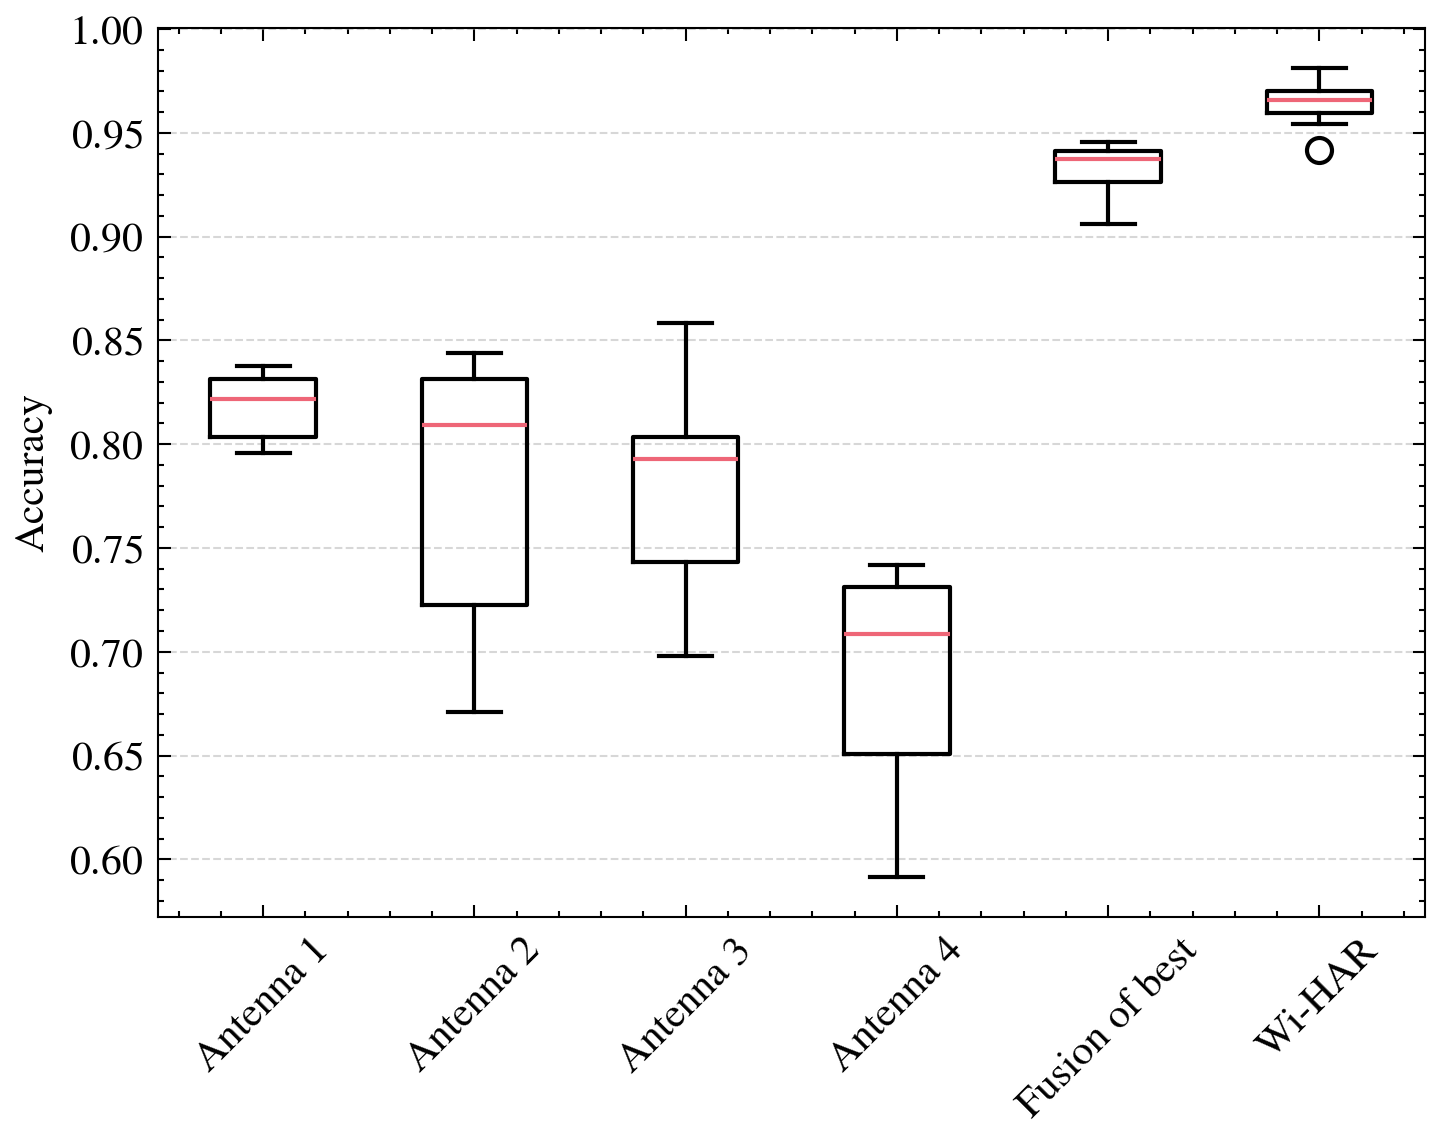

In [4]:
wi_har_results = list(wi_har_best_model.accuracies_per_seed.values())
single_results = [list(model.accuracies_per_seed.values()) for model in single_best_models]

plot_data = [*single_results, fusion_of_best_results, wi_har_results]
plot_labels = [f"Antenna {i+1}" for i in range(len(single_results))] + ["Fusion of best", "Wi-HAR"]

plt.figure(figsize=(5, 4))
plt.boxplot(plot_data, tick_labels=plot_labels, showmeans=False)
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ablation.pdf", bbox_inches="tight")
plt.show()

## 3. Results Summary

In [5]:
def summarize_metric(name: str, values: list[float]) -> dict[str, float | str]:
    """Summarize a list of metric values with key statistics."""
    tensor = torch.tensor(values, dtype=torch.float32)
    return {
        "name": name,
        "median": torch.median(tensor).item(),
        "p25": torch.quantile(tensor, 0.25).item(),
        "p75": torch.quantile(tensor, 0.75).item(),
        "mean": torch.mean(tensor).item(),
        "std": torch.std(tensor, unbiased=False).item(),
    }

rows = []
for antenna_idx, results in enumerate(single_results):
    rows.append(summarize_metric(f"Antenna {antenna_idx}", results))

rows.append(summarize_metric("Fusion of best", fusion_of_best_results))
rows.append(summarize_metric("Wi-HAR", wi_har_results))

ablation_df = pd.DataFrame(rows).sort_values("median", ascending=False).reset_index(drop=True)
ablation_df

,name,median,p25,p75,mean,std
0,Wi-HAR,0.964583,0.959375,0.970313,0.964167,0.010408
1,Fusion of best,0.937500,0.926562,0.941146,0.933333,0.011932
2,Antenna 0,0.814583,0.803646,0.831250,0.818125,0.015813
3,Antenna 1,0.806250,0.722396,0.831250,0.781042,0.061615
4,Antenna 2,0.787500,0.743229,0.803646,0.779792,0.048089
5,Antenna 3,0.708333,0.650521,0.731250,0.687292,0.052195


In [6]:
single_mins = [min(results) for results in single_results]
absolute_min_single = min(single_mins)
absolute_min_antenna = single_mins.index(absolute_min_single)

wi_har_min = min(wi_har_results)
fusion_of_best_max = max(fusion_of_best_results)

single_medians = [torch.median(torch.tensor(results)).item() for results in single_results]
best_single_median = max(single_medians)
fusion_of_best_median = torch.median(torch.tensor(fusion_of_best_results)).item()
wi_har_median = torch.median(torch.tensor(wi_har_results)).item()

print(f"Absolute min (single antenna setups): {absolute_min_single:.6f} (Antenna {absolute_min_antenna})")
print(f"Absolute min (Wi-HAR): {wi_har_min:.6f}")
print(f"Absolute max (Fusion of best): {fusion_of_best_max:.6f}")
print(f"Best single-antenna median: {best_single_median:.6f}")
print(f"Fusion-of-best median: {fusion_of_best_median:.6f}")
print(f"Wi-HAR median: {wi_har_median:.6f}")

Absolute min (single antenna setups): 0.591667 (Antenna 3)
Absolute min (Wi-HAR): 0.941667
Absolute max (Fusion of best): 0.945833
Best single-antenna median: 0.814583
Fusion-of-best median: 0.937500
Wi-HAR median: 0.964583
